# PCA — Principal Component Analysis (from scratch)

You have data in many dimensions. PCA finds the few directions that matter most.

Imagine shining a flashlight on a 3D object — the shadow on the wall is a 2D projection. PCA finds the **best angle** to hold the flashlight so the shadow captures the most detail. The first principal component (PC1) is the direction where data spreads the most. PC2 is the next best direction, perpendicular to PC1, and so on.

## The connection to SVD

PCA is just SVD applied to centered data:

1. **Center** the data — subtract the mean of each feature
2. Compute **AᵀA** on centered data (A = centered data matrix)
3. Eigenvectors of AᵀA → **principal components** (directions of max variance)
4. Eigenvalues → how much **variance** each direction captures

## Projection

To reduce dimensions, project each data point onto the top-k principal components:
`projected = data @ PC` — dot product gives each point's coordinate along that direction.

The magic: if data lies near a low-dimensional surface (e.g., a line in 2D), PCA finds it and compresses with almost zero loss. If the data is a blobby cloud, you need more components.

In [72]:
import numpy as np
import matplotlib.pyplot as plt

In [73]:
x = np.random.randn(100) + 5      # shifted to center around 5
y = 2 * x + 2 * np.random.randn(100)  # y centers around 10
y

array([10.75342148, 11.70972023,  9.0333911 , 11.13483947,  8.14224505,
        7.8663761 , 12.39297801,  9.08066316, 13.00244877,  8.41261025,
        9.10453817, 10.14409549,  7.77856643,  8.1880507 , 10.68035183,
        8.35060417,  6.49100682, 13.99976085,  9.02518782, 11.03020361,
       10.06077278,  4.89240581,  9.57655635,  5.85210652, 12.0076099 ,
        9.77072813, 11.71255056, 12.6935512 , 10.24576568,  9.25232782,
        8.57146401,  8.73877081,  7.6616025 , 12.14520442, 18.22206504,
        7.1225729 ,  9.72107889,  8.71389989, 10.04782782,  7.68570772,
       16.67297214,  6.87917146, 10.84465129,  6.66758338,  8.64642927,
       12.28068962,  6.52426155,  5.72155105,  7.866771  ,  6.93057701,
       10.0727339 , 14.10411207, 10.15649905,  9.22954934,  9.87292056,
        8.13810376,  5.49744168, 10.92116262, 10.2112896 ,  7.46920461,
        7.03622385,  6.6268755 , 12.93000006, 15.03449401, 10.27672428,
        9.2904453 ,  5.1886897 , 11.98346514,  7.15654828,  9.06

In [74]:
# takes two 1D arrays and puts them side by side as columns
data = np.column_stack([x, y]) 
data

array([[ 4.82421868, 10.75342148],
       [ 5.47560057, 11.70972023],
       [ 5.23546975,  9.0333911 ],
       [ 5.43241529, 11.13483947],
       [ 3.5577479 ,  8.14224505],
       [ 4.94996985,  7.8663761 ],
       [ 7.30162158, 12.39297801],
       [ 4.19682824,  9.08066316],
       [ 6.31456948, 13.00244877],
       [ 5.67627812,  8.41261025],
       [ 5.04308491,  9.10453817],
       [ 5.22097027, 10.14409549],
       [ 4.0976265 ,  7.77856643],
       [ 5.29981525,  8.1880507 ],
       [ 5.51473765, 10.68035183],
       [ 4.55527258,  8.35060417],
       [ 4.1325551 ,  6.49100682],
       [ 6.33777814, 13.99976085],
       [ 5.36246762,  9.02518782],
       [ 5.8614242 , 11.03020361],
       [ 5.6580894 , 10.06077278],
       [ 5.50387489,  4.89240581],
       [ 5.59606201,  9.57655635],
       [ 3.78022692,  5.85210652],
       [ 6.11251435, 12.0076099 ],
       [ 4.95741635,  9.77072813],
       [ 4.83936643, 11.71255056],
       [ 5.67445406, 12.6935512 ],
       [ 4.67926072,

In [75]:
data.shape

(100, 2)

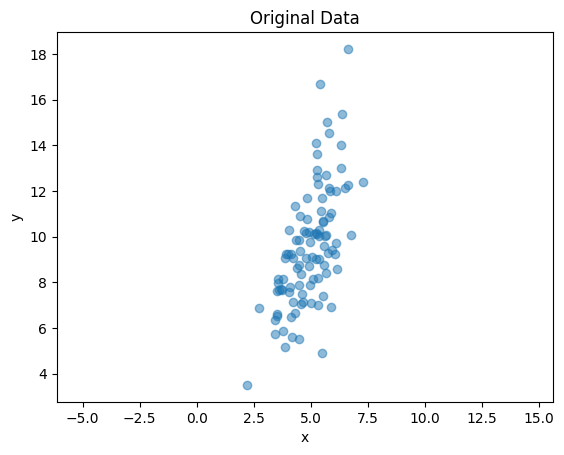

In [76]:
plt.scatter(data[:, 0], data[:, 1], alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Original Data')
plt.axis('equal')
plt.show()

In [77]:
mean = data.mean(axis=0) # axis=0 means "collapse rows, keep columns."
mean

array([4.93909679, 9.54429261])

In [78]:
centered = data - mean
centered

array([[-0.11487812,  1.20912887],
       [ 0.53650377,  2.16542762],
       [ 0.29637295, -0.51090151],
       [ 0.49331849,  1.59054687],
       [-1.38134889, -1.40204756],
       [ 0.01087305, -1.67791651],
       [ 2.36252479,  2.8486854 ],
       [-0.74226855, -0.46362945],
       [ 1.37547269,  3.45815616],
       [ 0.73718132, -1.13168236],
       [ 0.10398812, -0.43975444],
       [ 0.28187348,  0.59980288],
       [-0.84147029, -1.76572617],
       [ 0.36071846, -1.35624191],
       [ 0.57564086,  1.13605922],
       [-0.38382422, -1.19368844],
       [-0.80654169, -3.05328579],
       [ 1.39868135,  4.45546825],
       [ 0.42337083, -0.51910479],
       [ 0.92232741,  1.485911  ],
       [ 0.71899261,  0.51648017],
       [ 0.5647781 , -4.65188679],
       [ 0.65696521,  0.03226374],
       [-1.15886988, -3.69218608],
       [ 1.17341755,  2.46331729],
       [ 0.01831955,  0.22643552],
       [-0.09973036,  2.16825795],
       [ 0.73535727,  3.14925859],
       [-0.25983607,

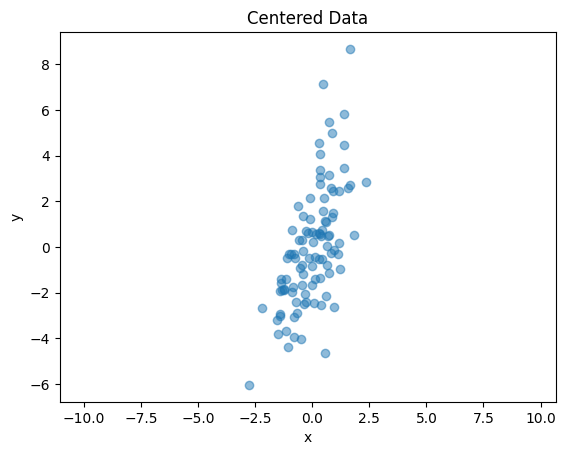

In [79]:
plt.scatter(centered[:, 0], centered[:, 1], alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Centered Data')
plt.axis('equal')
plt.show()

In [80]:
def power_iteration(M, num_iters, v):
    if num_iters == 0:
        return v

    v_new = np.dot(M, v)
    v_new = v_new / np.linalg.norm(v_new)

    if np.allclose(v, v_new):
        return v_new
    
    return power_iteration(M, num_iters - 1, v_new)

In [81]:
A = centered.T @ centered
v = np.random.rand(2)
A, v

(array([[ 88.86367019, 155.76248111],
        [155.76248111, 674.19606414]]),
 array([0.34460023, 0.87174537]))

In [82]:
e_v1 = power_iteration(A, 10, v)
e_v1

array([0.24211456, 0.97024767])

In [83]:
e_val1 = np.dot(np.dot(np.transpose(e_v1), A), e_v1)
e_val1

np.float64(713.0648628660697)

In [84]:
A_deflated = A - e_val1 * np.outer(e_v1, np.transpose(e_v1))
A_deflated

array([[ 47.06419428, -11.74435867],
       [-11.74435867,   2.93067719]])

In [85]:
e_v2 = power_iteration(A_deflated, 10, np.random.random(2))
e_v2

array([ 0.97024762, -0.24211476])

In [86]:
e_val2 = np.dot(np.dot(np.transpose(e_v2), A_deflated), e_v2)
e_val2

np.float64(49.99487146849535)

In [87]:
V = np.column_stack([e_v1, e_v2])
V

array([[ 0.24211456,  0.97024762],
       [ 0.97024767, -0.24211476]])

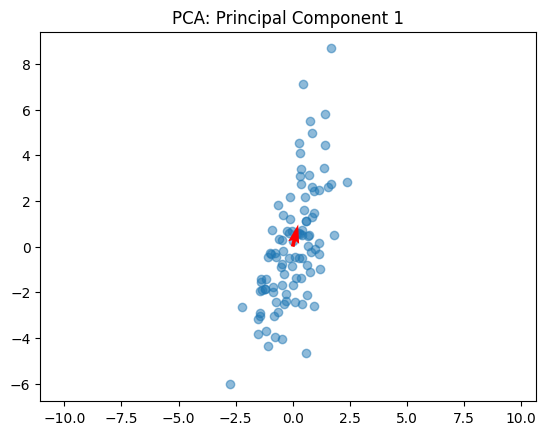

In [88]:
import matplotlib.pyplot as plt

# Scatter plot of centered data
plt.scatter(centered[:, 0], centered[:, 1], alpha=0.5)

# Draw PC1 as an arrow from the origin
# plt.quiver(start_x, start_y, direction_x, direction_y)
# scale=1 means use actual coordinates, not auto-scaled
plt.quiver(0, 0, e_v1[0], e_v1[1], scale=1, scale_units='xy', angles='xy', color='red', linewidth=2)

plt.axis('equal')  # keep x and y same scale, crucial for seeing the real direction
plt.title('PCA: Principal Component 1')
plt.show()

In [89]:
projections = centered @ e_v1   # shape: (100,) — each point's coordinate along PC1
projections

array([ 1.1453408 ,  2.23089648, -0.42394479,  1.66266398, -1.69477805,
       -1.62536206,  3.33593201, -0.62954942,  3.68828992, -0.91952984,
       -0.40149368,  0.65020302, -1.91692391, -1.22855536,  1.24162984,
       -1.25110286, -3.15771891,  4.6615488 , -0.40115597,  1.66501058,
        0.67519226, -4.37674133,  0.19036466, -3.86291421,  2.67412933,
        0.22413397,  2.07960106,  3.23360151,  0.61769252, -0.47497873,
       -0.6534403 , -0.62787561, -2.14709203,  2.72757303,  8.82478433,
       -2.52274899,  0.45285298, -0.80941863,  0.58621791, -2.10134078,
        7.02882471, -3.1191286 ,  1.47118092, -2.94846156, -0.99988992,
        3.05886947, -3.27347255, -4.0728529 , -1.73894495, -2.3057856 ,
        0.95545357,  4.49483446,  0.5518702 , -0.53159749,  0.17788385,
       -1.64199467, -4.04206822,  1.23682356,  0.64495865, -2.08848746,
       -2.52225337, -3.17631077,  3.36869651,  5.50748699,  0.80898025,
       -0.04841575, -4.48314728,  2.58848689, -2.38406688, -0.49

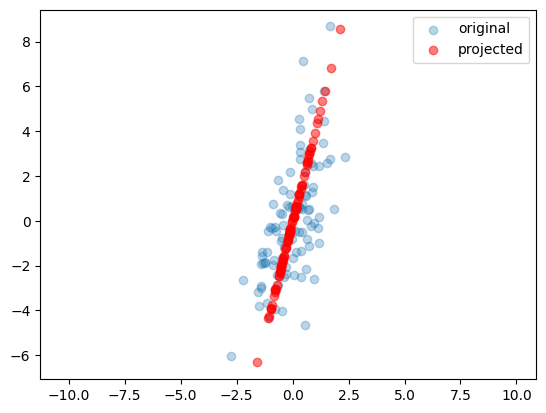

In [90]:
# projected points land on the PC1 line
projected_2d = np.outer(projections, e_v1)  # back to 2D, but all on the PC1 line
plt.scatter(centered[:, 0], centered[:, 1], alpha=0.3, label='original')
plt.scatter(projected_2d[:, 0], projected_2d[:, 1], alpha=0.5, color='red', label='projected')
plt.legend()
plt.axis('equal')
plt.show()